Understanding and classfication of diabetes person and no-Diabets person using given cloums

Divide the diabetes data into train and test datasets and build a
Random Forest and Decision Tree model with Outcome as the output variable

In [117]:
import pandas as pd 
import numpy as np  
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier 
from  sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.tree import plot_tree 
from sklearn.metrics import accuracy_score
df= pd.read_csv("E:/Data Science/13-Decision Tree/Diabetes.csv")
df

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,NO
764,2,122,70,27,0,36.8,0.340,27,NO
765,5,121,72,23,112,26.2,0.245,30,NO
766,1,126,60,0,0,30.1,0.349,47,YES


In [6]:
df.head(3)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES


In [8]:
df.sample(2)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
336,0,117,0,0,0,33.8,0.932,44,NO
657,1,120,80,48,200,38.9,1.162,41,NO


In [10]:
df.isnull().sum()

Number of times pregnant        0
Plasma glucose concentration    0
Diastolic blood pressure        0
Triceps skin fold thickness     0
2-Hour serum insulin            0
Body mass index                 0
Diabetes pedigree function      0
Age (years)                     0
Class variable                  0
dtype: int64

In [12]:
df.describe()

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years)
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [14]:
df.duplicated().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0    Number of times pregnant      768 non-null    int64  
 1    Plasma glucose concentration  768 non-null    int64  
 2    Diastolic blood pressure      768 non-null    int64  
 3    Triceps skin fold thickness   768 non-null    int64  
 4    2-Hour serum insulin          768 non-null    int64  
 5    Body mass index               768 non-null    float64
 6    Diabetes pedigree function    768 non-null    float64
 7    Age (years)                   768 non-null    int64  
 8    Class variable                768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


In [18]:
#all are numrical coul
import seaborn as sns 
import matplotlib.pyplot as plt 
num=[' Number of times pregnant']

In [24]:
def dist_plot(i): 
    sns.displot(df[i])

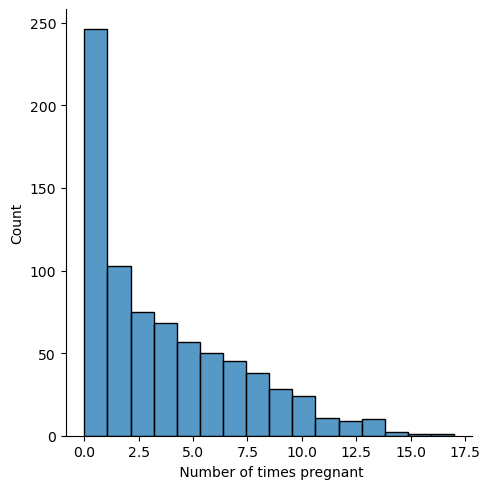

In [26]:
dist_plot(num[0])

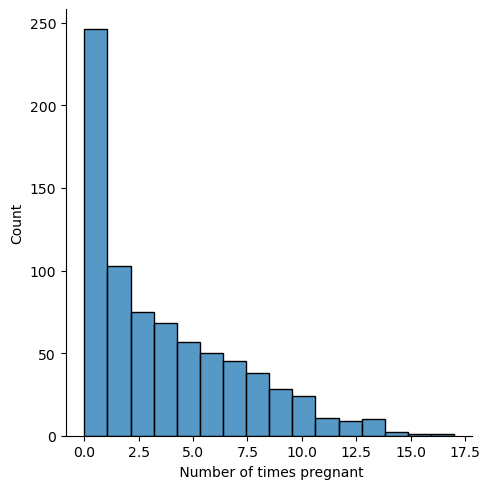

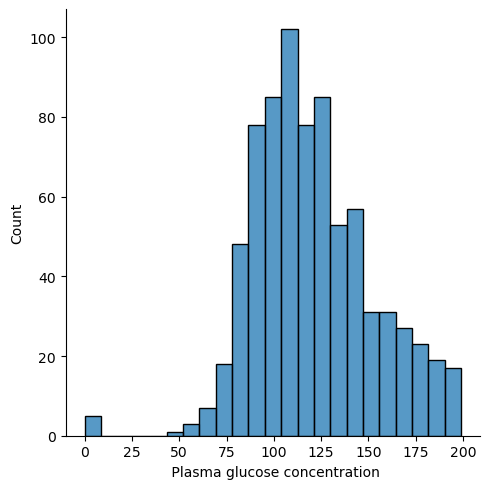

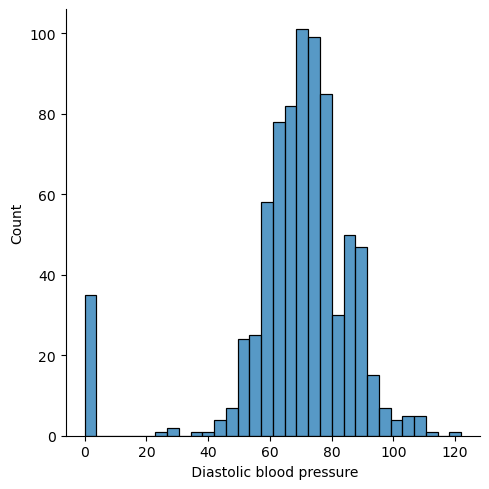

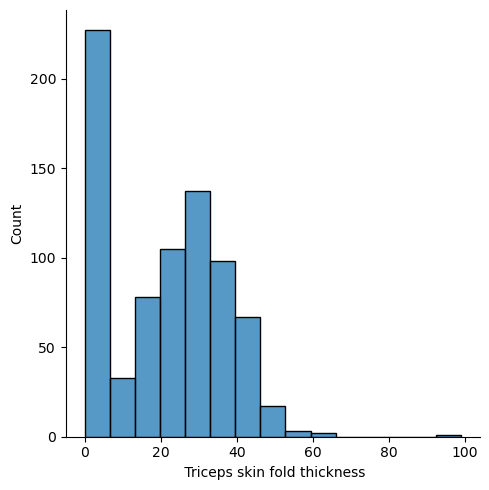

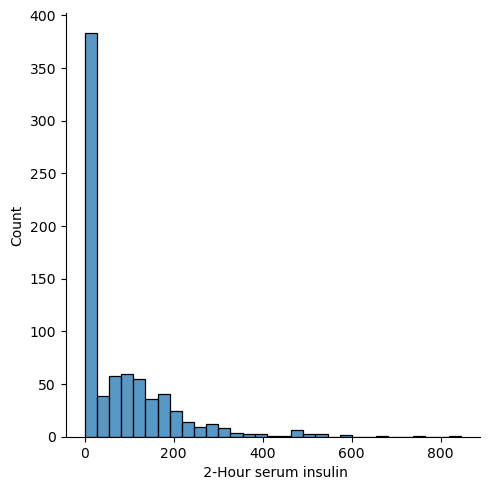

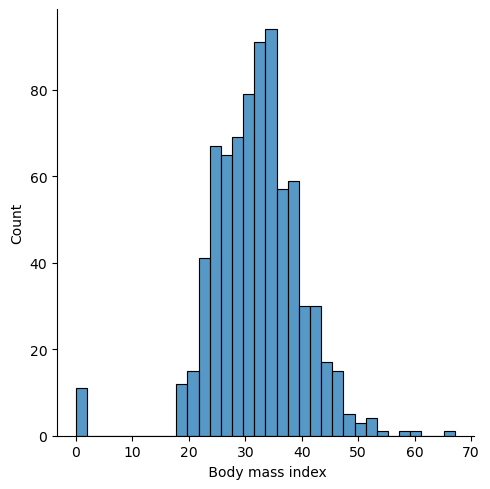

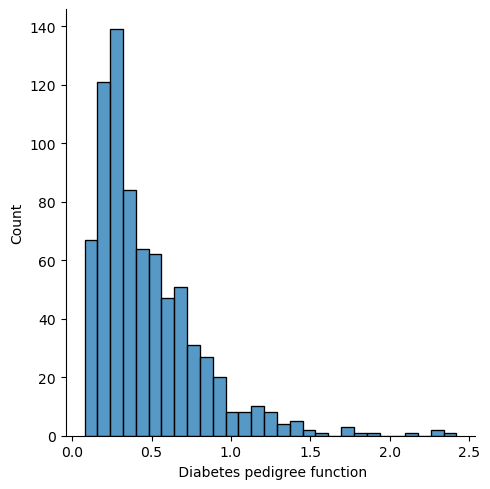

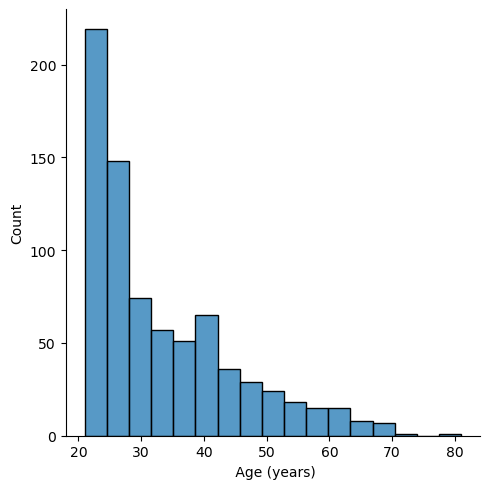

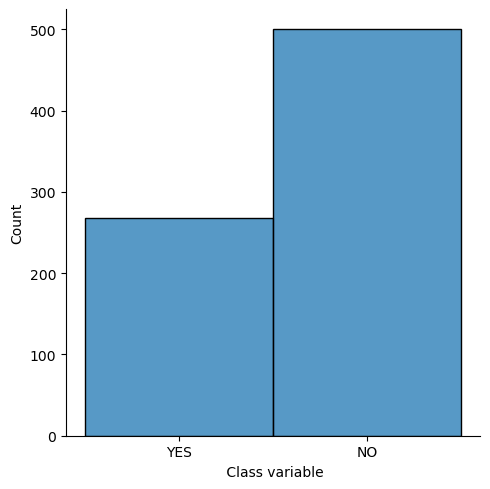

In [28]:
for i in df.columns: 
    dist_plot(i)
    plt.show()

In [30]:
# use power transformer to model to get good result 

In [32]:
def box_plot (i): 
    sns.boxplot(df[i])

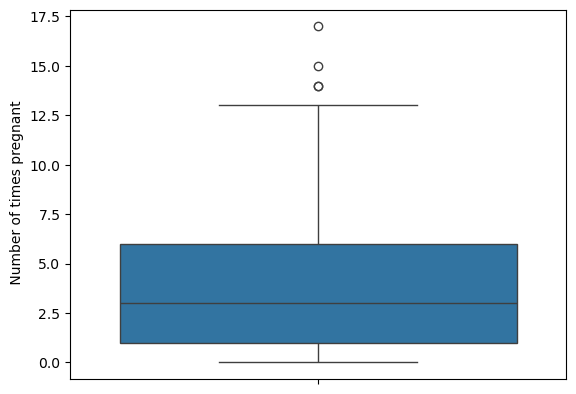

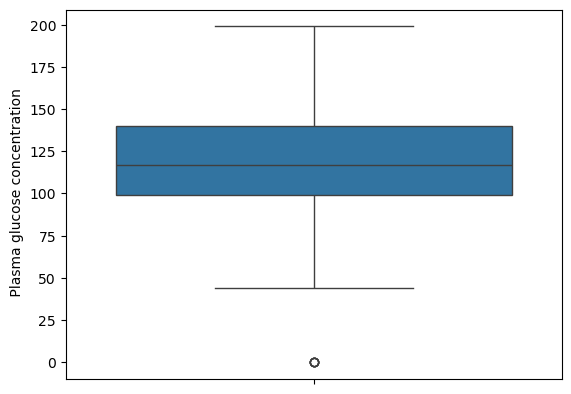

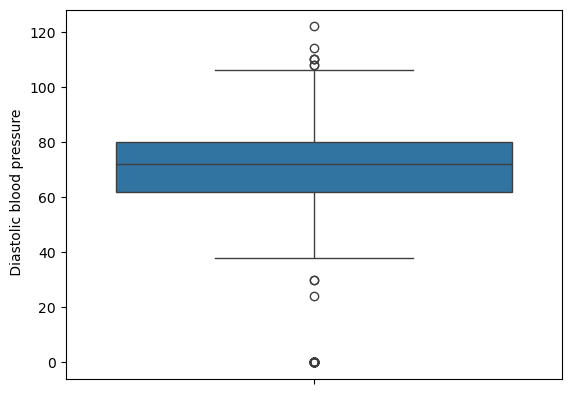

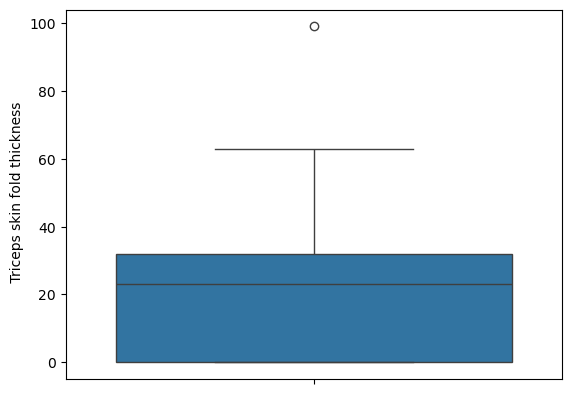

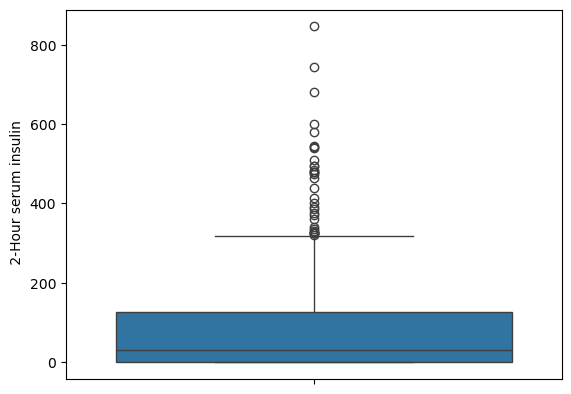

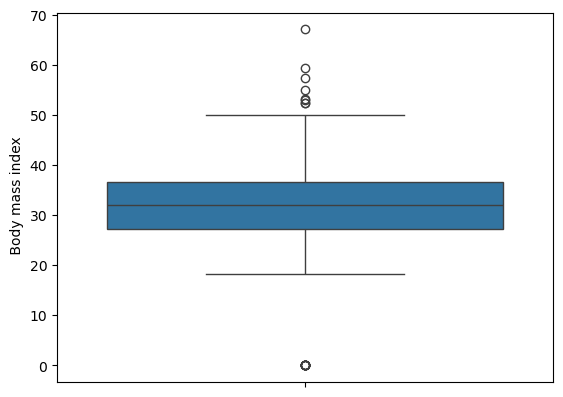

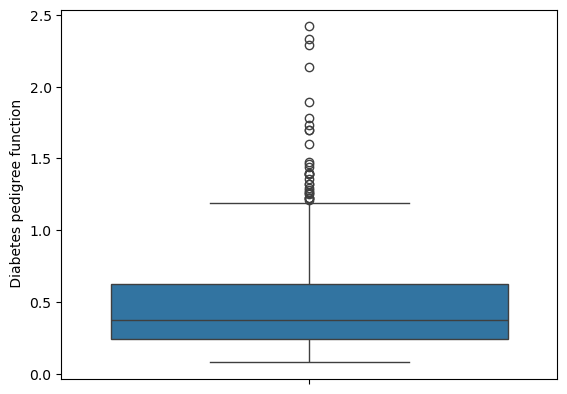

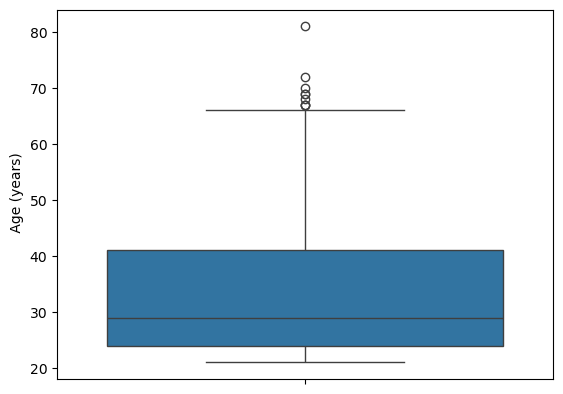

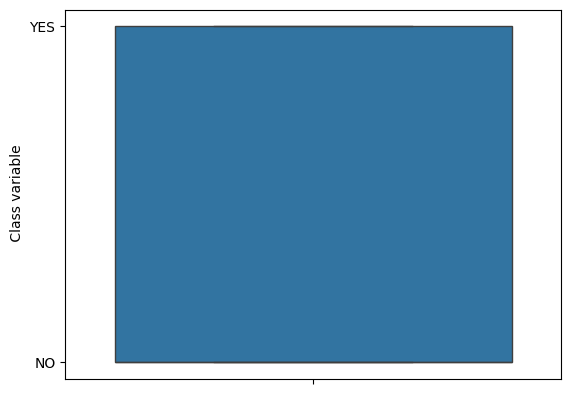

In [34]:
for i in df.columns : 
    box_plot(i)
    plt.show()

In [36]:
#oulier present in data  
for i in df.columns : 
    print(i)

 Number of times pregnant
 Plasma glucose concentration
 Diastolic blood pressure
 Triceps skin fold thickness
 2-Hour serum insulin
 Body mass index
 Diabetes pedigree function
 Age (years)
 Class variable


In [38]:
# outler present colums 
# 1)Diastolic blood pressure
# 2) 2-Hour serum insulin
# 3)Diabetes pedigree function 
# 4)Age (years)

In [40]:
# label incoder 
# outerlie detection 
# power trandforemer to the data 

In [42]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import PowerTransformer 

In [44]:
# label encoder to last colums to solve the proplem 
lab=LabelEncoder()
df[' Class variable']= lab.fit_transform(df[' Class variable'])

In [46]:
df.sample(4)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
695,7,142,90,24,480,30.4,0.128,43,1
658,11,127,106,0,0,39.0,0.190,51,0
636,5,104,74,0,0,28.8,0.153,48,0
283,7,161,86,0,0,30.4,0.165,47,1


In [48]:
df[' Class variable'].value_counts()

 Class variable
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel=' Class variable'>

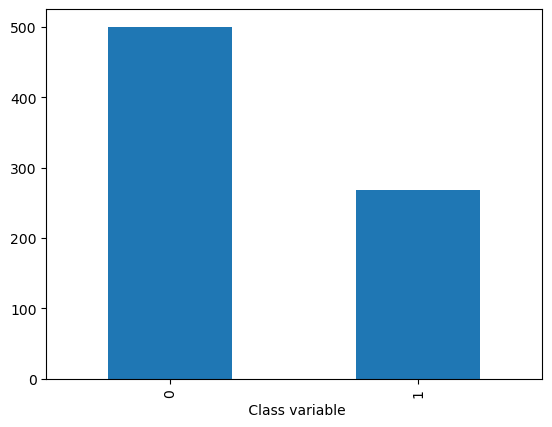

In [50]:
# umblace Data 
df[' Class variable'].value_counts().plot(kind='bar')

In [52]:
# outler present colums 
# 1)Diastolic blood pressure
# 2) 2-Hour serum insulin
# 3)Diabetes pedigree function 
# 4)Age (years) 

<Axes: ylabel=' Diastolic blood pressure'>

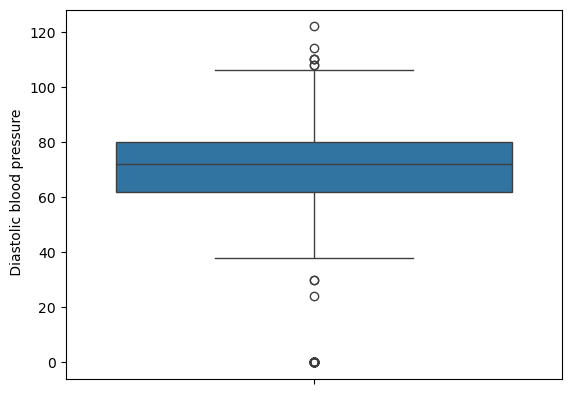

In [54]:
sns.boxplot(df[' Diastolic blood pressure'])

<Axes: ylabel=' 2-Hour serum insulin'>

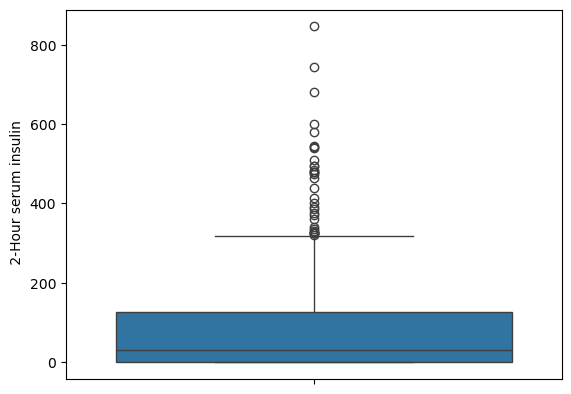

In [56]:
sns.boxplot(df[' 2-Hour serum insulin'])


<Axes: ylabel=' Diabetes pedigree function'>

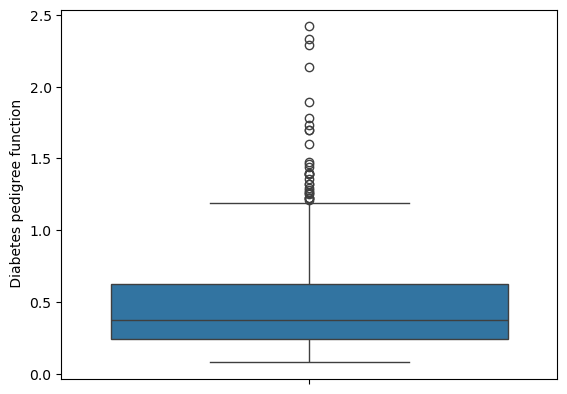

In [58]:
sns.boxplot(df[' Diabetes pedigree function'])

<Axes: ylabel=' Age (years)'>

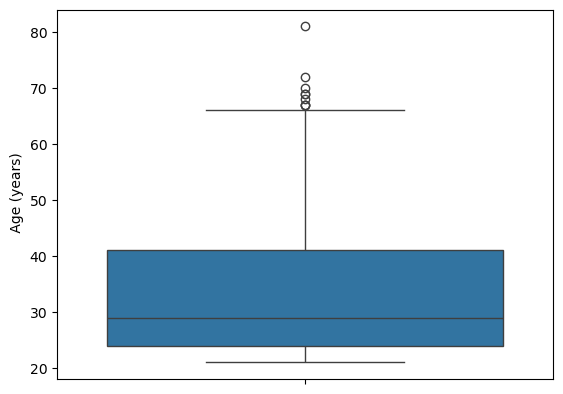

In [60]:
sns.boxplot(df[' Age (years)'])


In [63]:
def Remove_outler(i): 
    upper_limit = df[i].quantile(0.99)
    lower_limit =df[i].quantile(0.01) 
    new=np.where(df[i]>=upper_limit,upper_limit ,
         np.where(
               df[i]<=lower_limit,lower_limit
        , df[i]))
    return new

In [65]:
df[' Age (years)']=Remove_outler(' Age (years)')

In [67]:
df[' Diabetes pedigree function']=Remove_outler(' Diabetes pedigree function')

In [69]:
df[' Diastolic blood pressure']=Remove_outler(' Diastolic blood pressure')

In [71]:
power_transformer=PowerTransformer()

In [73]:
new_df=power_transformer.fit_transform(df.iloc[:,:-1])

In [75]:
new_df=pd.DataFrame(new_df)

In [77]:
X=df.iloc[:,:-1]
y=df[' Class variable'].values 

In [87]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [89]:
clf1=DecisionTreeClassifier()
clf2=RandomForestClassifier()
clf3=XGBClassifier()

In [91]:
clf1.fit(X_train,y_train)

DecisionTreeClassifier()

In [93]:
clf2.fit(X_train,y_train)

RandomForestClassifier()

In [95]:
clf3.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [97]:
y_predict1=clf1.predict(X_test)
y_predict2=clf2.predict(X_test)
y_predict3=clf3.predict(X_test)

In [103]:
 accuracy_score(y_test,y_predict1)

0.7792207792207793

In [105]:
accuracy_score(y_test,y_predict2)

0.7532467532467533

In [107]:
accuracy_score(y_test,y_predict3)

0.7077922077922078

In [109]:
y_predict_train_1=clf1.predict(X_train)
y_predict_train_2=clf2.predict(X_train)
y_predict_train_3=clf3.predict(X_train)

In [111]:
accuracy_score(y_train,y_predict_train_1)

1.0

In [113]:
accuracy_score(y_train,y_predict_train_2)

1.0

In [115]:
# all are overfited condition so use the predictio for power transforemer

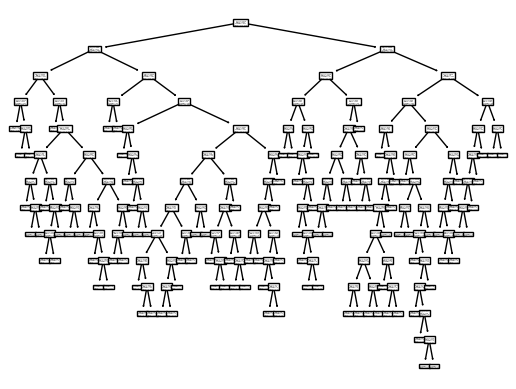

In [119]:
plot_tree(clf1)
plt.show()

In [120]:
clf1=DecisionTreeClassifier(max_depth=28,max_features=13,max_leaf_nodes=66)

In [123]:
clf1.fit(X_train,y_train)
y_predict1=clf1.predict(X_test)
accuracy_score(y_test,y_predict1)

0.7857142857142857

In [125]:
clf7=RandomForestClassifier(n_estimators=300,n_jobs=300)
clf7.fit(X_train,y_train)
y_predict1=clf7.predict(X_test)
accuracy_score(y_test,y_predict1)

0.7467532467532467

In [127]:
x_train=power_transformer.fit_transform(X_train)
x_test=power_transformer.transform(X_test)

In [129]:
clf1.fit(x_train,y_train)
y_predict1=clf1.predict(x_test)
accuracy_score(y_test,y_predict1)

0.7662337662337663

In [131]:
y_predict12=clf1.predict(x_train)
accuracy_score(y_train,y_predict12)

0.9625407166123778